This question should be answered using the Weekly data set, which is part of the ISLP package. This data is similar in nature to the Smarket data from this chapter’s lab, except that it contains 1,089 weekly returns for 21 years, from the beginning of 1990 to the end of 2010.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen
from io import StringIO
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import statsmodels.api as sm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from itertools import combinations


### (a)
Produce some numerical and graphical summaries of the Weekly data. Do there appear to be any patterns?

In [2]:
# Load dataset from ISLR
url = "https://vincentarelbundock.github.io/Rdatasets/csv/ISLR/Weekly.csv"
s = urlopen(url).read().decode('utf-8')
weekly = pd.read_csv(StringIO(s), index_col=0)

weekly['Direction'] = weekly['Direction'].astype('category')
weekly['Year'] = weekly['Year'].astype(int)
weekly['Y'] = (weekly['Direction'] == 'Up').astype(int)

weekly.head()


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction,Y
rownames,,,,,,,,,,
1,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down,0
2,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down,0
3,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up,1
4,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up,1
5,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up,1


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Y
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899,0.555556
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927,0.497132
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000,0.000000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000,0.000000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000,1.000000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000,1.000000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000,1.000000


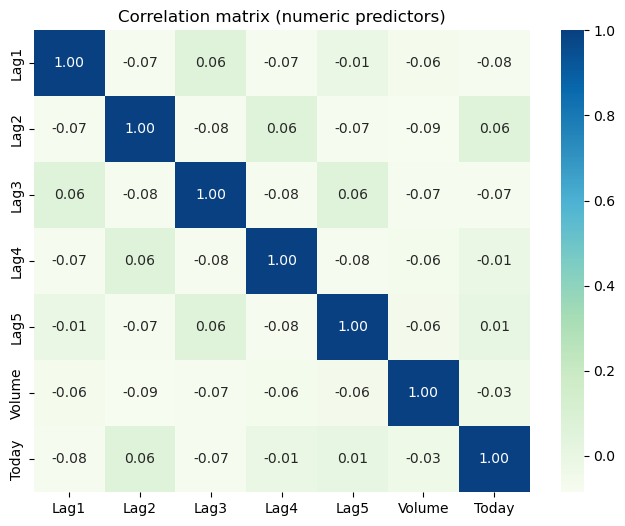

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


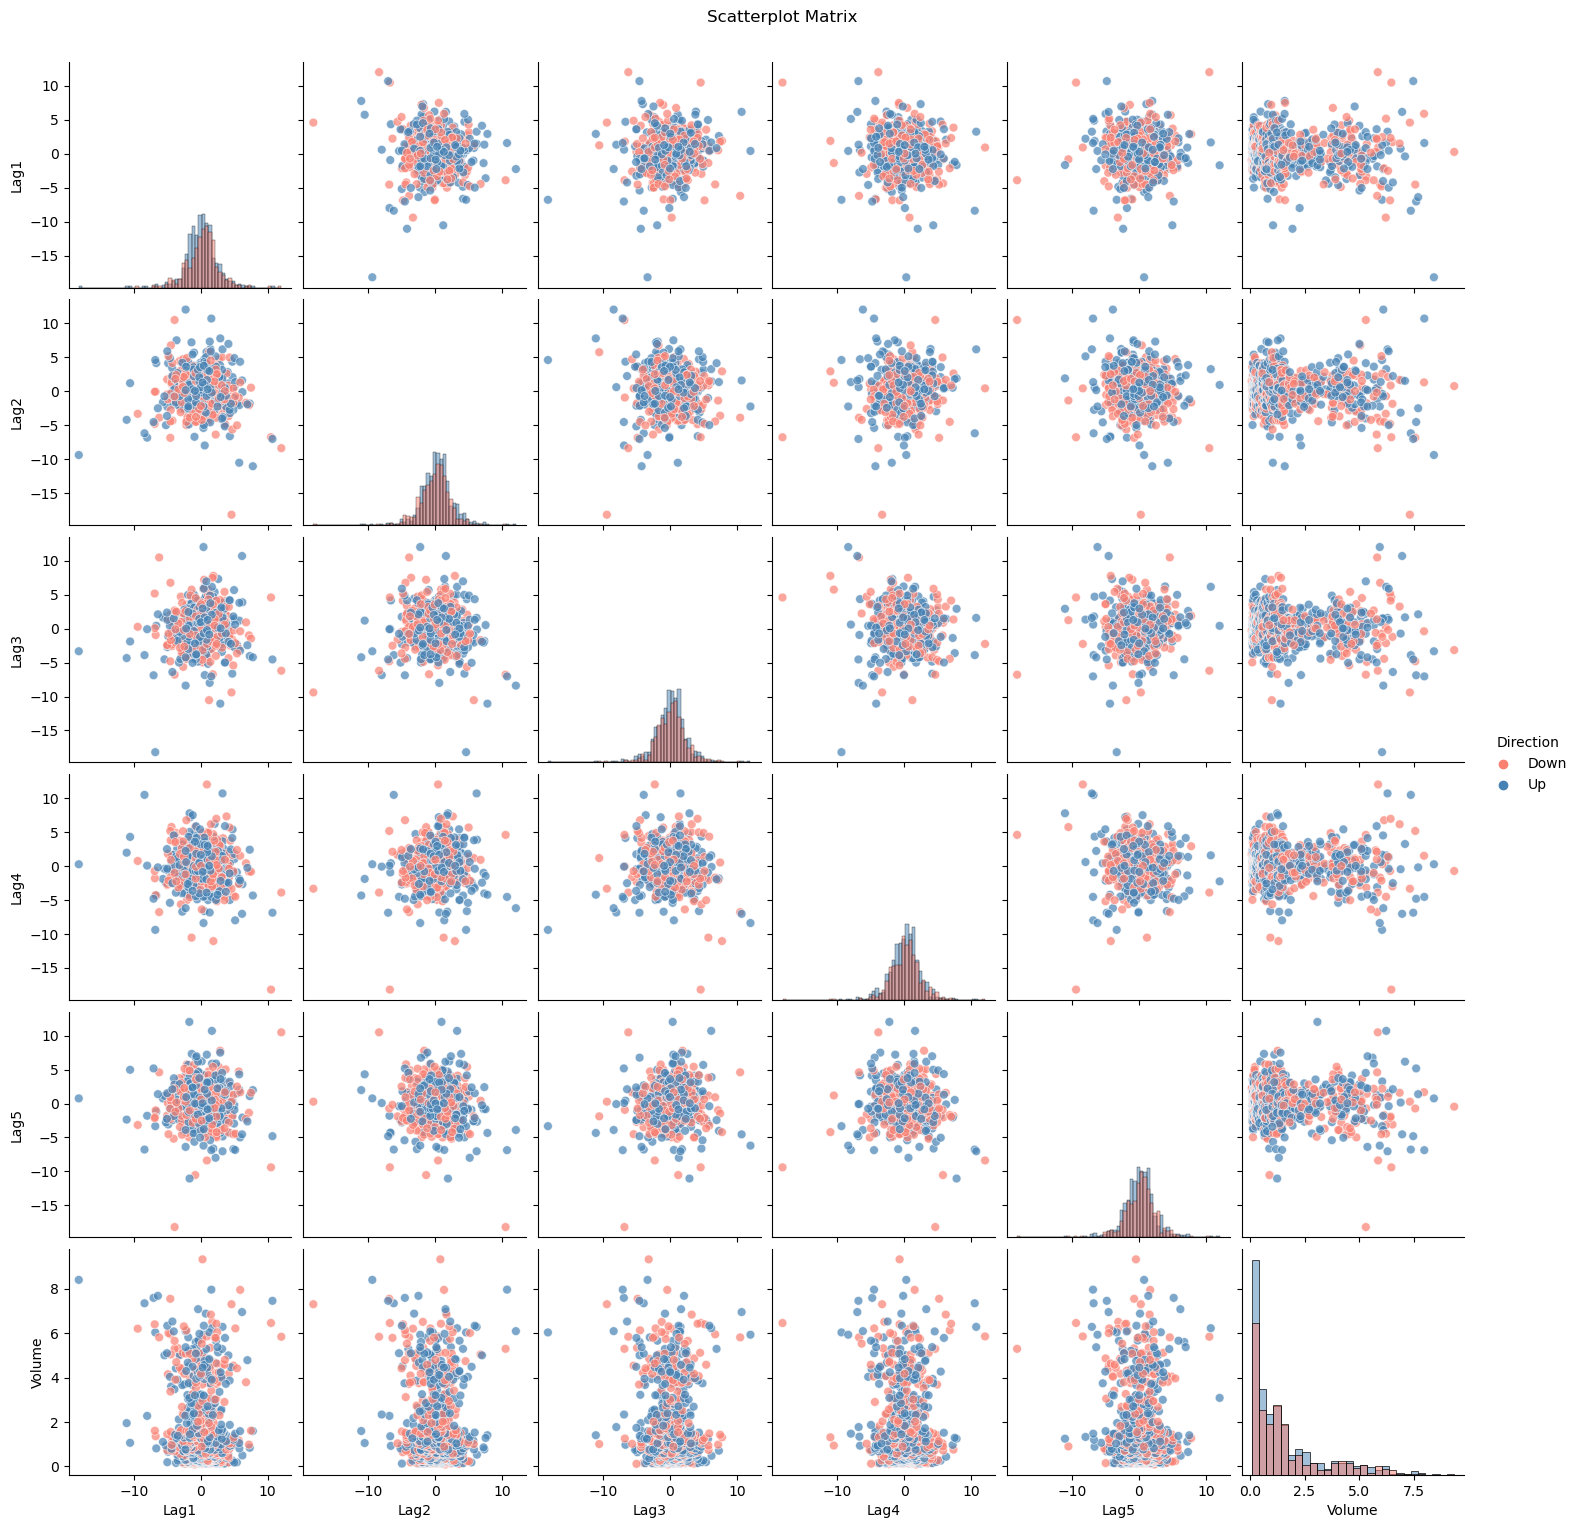

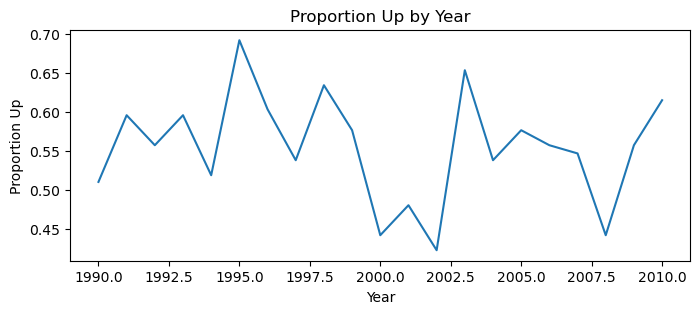

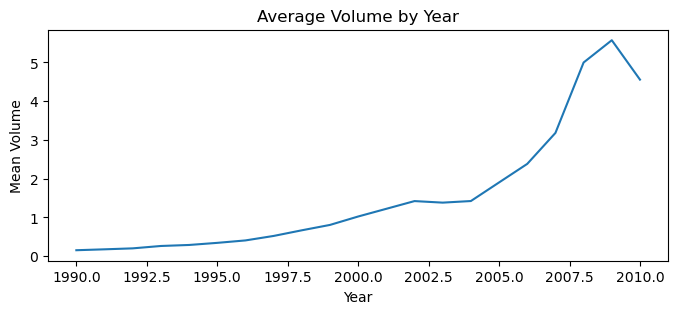

In [14]:
display(weekly.describe())

numeric_cols = ['Lag1','Lag2','Lag3','Lag4','Lag5','Volume','Today']
corr = weekly[numeric_cols].corr()
#heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='GnBu')
plt.title('Correlation matrix (numeric predictors)')
plt.show()
#pairwise scatter plot
sns.pairplot(weekly,vars=['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume'],
             hue='Direction',          # 分群顏色
             palette={'Up': 'steelblue', 'Down': 'salmon'},  # 顏色可自訂
             plot_kws={'alpha': 0.7, 's': 40},               # 散點透明度與大小
             diag_kind='hist')
plt.suptitle("Scatterplot Matrix", y=1.02)
plt.show()

#折線圖
weekly.groupby('Year')['Y'].mean().plot(title='Proportion Up by Year', figsize=(8,3))
plt.ylabel('Proportion Up')
plt.show()

weekly.groupby('Year')['Volume'].mean().plot(title='Average Volume by Year', figsize=(8,3))
plt.ylabel('Mean Volume')
plt.show()


### (b) 
Use the full data set to perform a logistic regression with
Direction as the response and the five lag variables plus Volume as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones?

In [15]:
X_full = sm.add_constant(weekly[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']])
y_full = weekly['Y']

logit_full = sm.Logit(y_full, X_full).fit(disp=False)
logit_full.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      Y   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Thu, 06 Nov 2025   Pseudo R-squ.:                0.006580
Time:                        06:57:42   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.026     -1.563      0.118      -0.093       0.010
Lag2           0.0584      0.027      2.175      0.030       0.006       0.111
Lag3          -0.0161      0.027     -0.602      0.547      -0.068       0.036
Lag4          -0.0278      0.026     -1.050      0.294      -0.080       0.024
Lag5          -0.0145      0.026     -0.549      0.583      -0.066       0.037
Volume        -0.0227      0.037     -0.616      0.538      -0.095       0.050
==============================================================================
"""

lag2 is statistically significant

### (c) 
Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

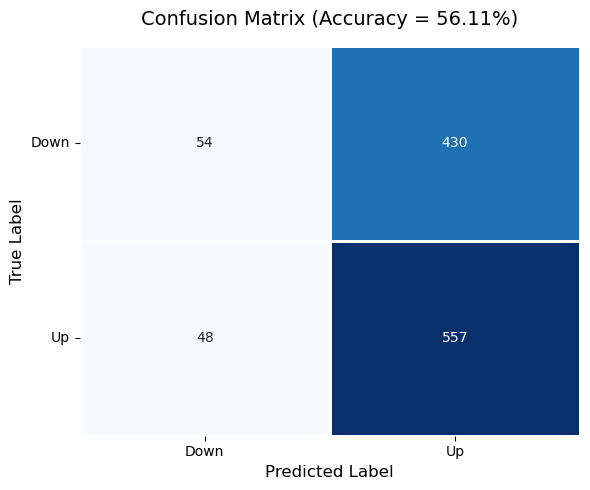

Classification Report:

              precision    recall  f1-score   support

        Down       0.53      0.11      0.18       484
          Up       0.56      0.92      0.70       605

    accuracy                           0.56      1089
   macro avg       0.55      0.52      0.44      1089
weighted avg       0.55      0.56      0.47      1089



In [17]:
pred_probs_full = logit_full.predict(X_full)
pred_full = (pred_probs_full >= 0.5).astype(int)

cm_full = confusion_matrix(y_full, pred_full)
acc_full = accuracy_score(y_full, pred_full)


# 畫出精美的 Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_full,
    annot=True,          # 顯示數字
    fmt="d",             # 顯示為整數
    cmap="Blues",        # 顏色主題（可改成 "Greens", "Purples"）
    cbar=False,          # 不顯示右側 color bar
    linewidths=1,        # 增加格線
    linecolor='white'    # 格線顏色
)

# 標題與標籤
plt.title(f"Confusion Matrix (Accuracy = {acc_full:.2%})", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks([0.5, 1.5], ["Down", "Up"])
plt.yticks([0.5, 1.5], ["Down", "Up"], rotation=0)
plt.tight_layout()
plt.show()

# 顯示分類報告
print("Classification Report:\n")
print(classification_report(y_full, pred_full, target_names=['Down', 'Up']))


### (d) 
Now fit the logistic regression model using a training data period from 1990 to 2008, with Lag2 as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from 2009 and 2010).

                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Thu, 06 Nov 2025   Pseudo R-squ.:                0.003076
Time:                        07:08:09   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.029      2.024      0.043       0.002       0.114


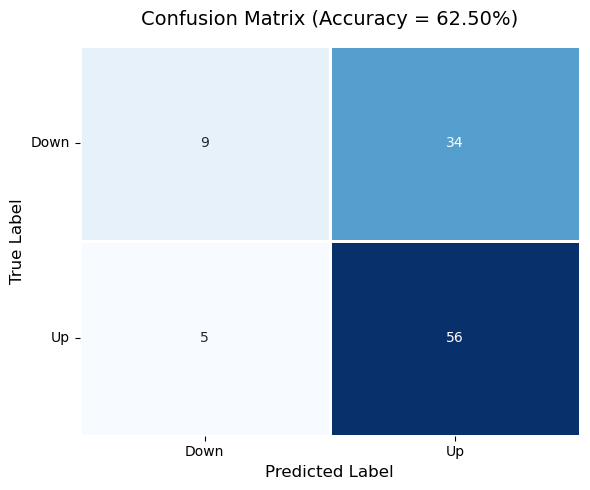

In [19]:
train = weekly[weekly['Year'] <= 2008]
test = weekly[weekly['Year'] > 2008]

Xtr_lag2 = sm.add_constant(train[['Lag2']])
Xte_lag2 = sm.add_constant(test[['Lag2']])

logit_lag2 = sm.Logit(train['Y'], Xtr_lag2).fit(disp=False)
print(logit_lag2.summary())

predp_lag2 = logit_lag2.predict(Xte_lag2)
pred_lag2 = (predp_lag2 >= 0.5).astype(int)

cm_lag2 = confusion_matrix(test['Y'], pred_lag2)
acc_lag2 = accuracy_score(test['Y'], pred_lag2)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lag2,
    annot=True,          # 顯示數字
    fmt="d",             # 顯示為整數
    cmap="Blues",        # 顏色主題（可改成 "Greens", "Purples"）
    cbar=False,          # 不顯示右側 color bar
    linewidths=1,        # 增加格線
    linecolor='white'    # 格線顏色
)
# 標題與標籤
plt.title(f"Confusion Matrix (Accuracy = {acc_lag2:.2%})", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks([0.5, 1.5], ["Down", "Up"])
plt.yticks([0.5, 1.5], ["Down", "Up"], rotation=0)
plt.tight_layout()
plt.show()


### (e) 
Repeat (d) using LDA.

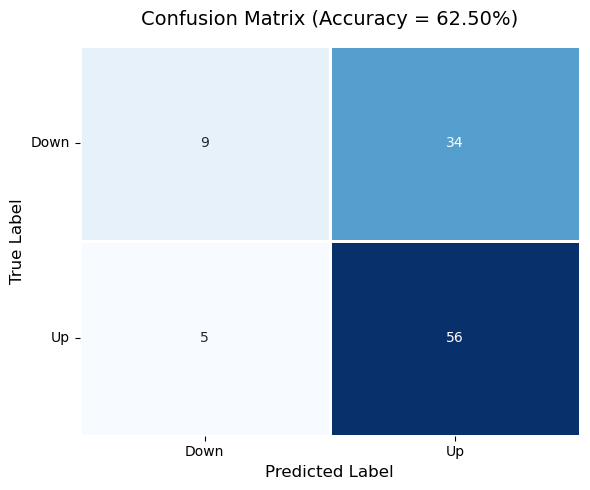

In [20]:
lda = LinearDiscriminantAnalysis().fit(train[['Lag2']], train['Y'])
pred_lda = lda.predict(test[['Lag2']])

cm_lda = confusion_matrix(test['Y'], pred_lda)
acc_lda = accuracy_score(test['Y'], pred_lda)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lda,
    annot=True,          # 顯示數字
    fmt="d",             # 顯示為整數
    cmap="Blues",        # 顏色主題（可改成 "Greens", "Purples"）
    cbar=False,          # 不顯示右側 color bar
    linewidths=1,        # 增加格線
    linecolor='white'    # 格線顏色
)
# 標題與標籤
plt.title(f"Confusion Matrix (Accuracy = {acc_lda:.2%})", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks([0.5, 1.5], ["Down", "Up"])
plt.yticks([0.5, 1.5], ["Down", "Up"], rotation=0)
plt.tight_layout()
plt.show()

### (f) 
Repeat (d) using QDA.

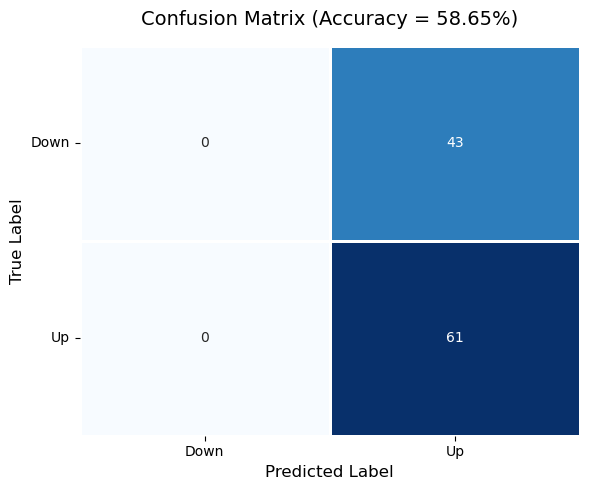

In [21]:
qda = QuadraticDiscriminantAnalysis().fit(train[['Lag2']], train['Y'])
pred_qda = qda.predict(test[['Lag2']])

cm_qda = confusion_matrix(test['Y'], pred_qda)
acc_qda = accuracy_score(test['Y'], pred_qda)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_qda,
    annot=True,          # 顯示數字
    fmt="d",             # 顯示為整數
    cmap="Blues",        # 顏色主題（可改成 "Greens", "Purples"）
    cbar=False,          # 不顯示右側 color bar
    linewidths=1,        # 增加格線
    linecolor='white'    # 格線顏色
)
# 標題與標籤
plt.title(f"Confusion Matrix (Accuracy = {acc_qda:.2%})", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks([0.5, 1.5], ["Down", "Up"])
plt.yticks([0.5, 1.5], ["Down", "Up"], rotation=0)
plt.tight_layout()
plt.show()

### (g) 
Repeat (d) using KNN with K = 1.

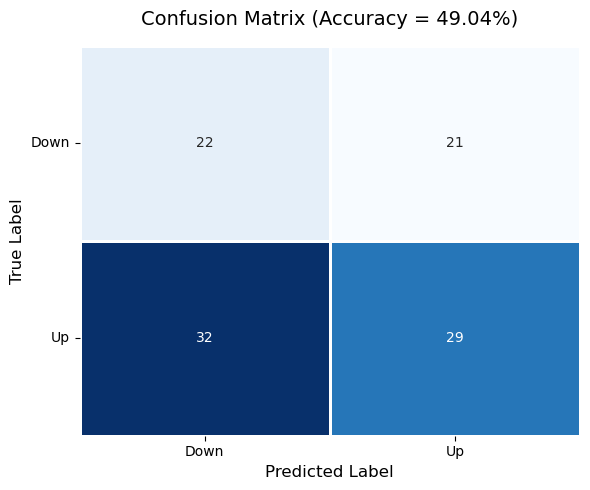

In [22]:
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(train[['Lag2']])
Xte_s = scaler.transform(test[['Lag2']])

knn1 = KNeighborsClassifier(n_neighbors=1).fit(Xtr_s, train['Y'])
pred_knn1 = knn1.predict(Xte_s)

cm_knn1 = confusion_matrix(test['Y'], pred_knn1)
acc_knn1 = accuracy_score(test['Y'], pred_knn1)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_knn1,
    annot=True,          # 顯示數字
    fmt="d",             # 顯示為整數
    cmap="Blues",        # 顏色主題（可改成 "Greens", "Purples"）
    cbar=False,          # 不顯示右側 color bar
    linewidths=1,        # 增加格線
    linecolor='white'    # 格線顏色
)
# 標題與標籤
plt.title(f"Confusion Matrix (Accuracy = {acc_knn1:.2%})", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks([0.5, 1.5], ["Down", "Up"])
plt.yticks([0.5, 1.5], ["Down", "Up"], rotation=0)
plt.tight_layout()
plt.show()

### (h) 
Repeat (d) using naive Bayes.

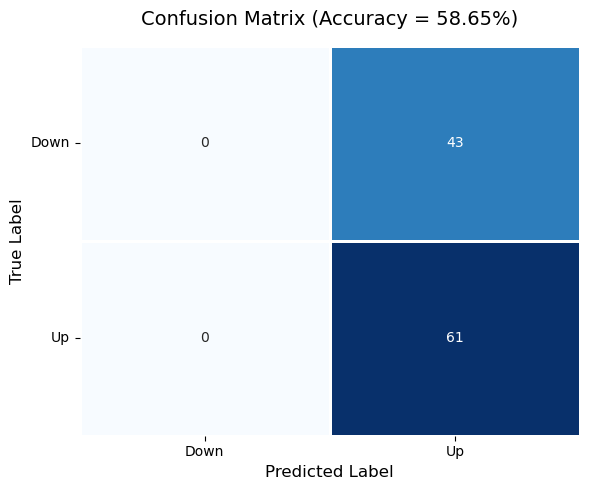

In [23]:
nb = GaussianNB().fit(train[['Lag2']], train['Y'])
pred_nb = nb.predict(test[['Lag2']])

cm_nb = confusion_matrix(test['Y'], pred_nb)
acc_nb = accuracy_score(test['Y'], pred_nb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nb,
    annot=True,          # 顯示數字
    fmt="d",             # 顯示為整數
    cmap="Blues",        # 顏色主題（可改成 "Greens", "Purples"）
    cbar=False,          # 不顯示右側 color bar
    linewidths=1,        # 增加格線
    linecolor='white'    # 格線顏色
)
# 標題與標籤
plt.title(f"Confusion Matrix (Accuracy = {acc_nb:.2%})", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks([0.5, 1.5], ["Down", "Up"])
plt.yticks([0.5, 1.5], ["Down", "Up"], rotation=0)
plt.tight_layout()
plt.show()


### (i) 
Which of these methods appears to provide the best results on this data?

In [24]:
methods_summary = pd.DataFrame({
    'method':['Logit_full','Logit_Lag2','LDA','QDA','KNN_k1','NaiveBayes'],
    'accuracy':[acc_full, acc_lag2, acc_lda, acc_qda, acc_knn1, acc_nb]
})
methods_summary


,method,accuracy
0,Logit_full,0.561065
1,Logit_Lag2,0.625000
2,LDA,0.625000
3,QDA,0.586538
4,KNN_k1,0.490385
5,NaiveBayes,0.586538


Logit_Lag2 and LDA provide the best results with both accuracy of 0.625

### (j) 
Experiment with different combinations of predictors, including possible transformations and interactions, for each of the methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held out data. Note that you should also experiment with values for K in the KNN classifier.

In [25]:
features = ['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']
combos = list(combinations(features,1)) + list(combinations(features,2))
train_Xy, test_Xy = train.copy(), test.copy()

results = []

for feat in combos:
    feat = list(feat)
    Xtr, Xte = train_Xy[feat], test_Xy[feat]
    ytr, yte = train_Xy['Y'], test_Xy['Y']
    
    # Logistic
    try:
        model = sm.Logit(ytr, sm.add_constant(Xtr)).fit(disp=False)
        pred = (model.predict(sm.add_constant(Xte)) >= 0.5).astype(int)
        results.append(['Logit', feat, accuracy_score(yte, pred)])
    except:
        pass
    
    # LDA
    lda = LinearDiscriminantAnalysis().fit(Xtr, ytr)
    results.append(['LDA', feat, accuracy_score(yte, lda.predict(Xte))])
    
    # QDA
    qda = QuadraticDiscriminantAnalysis().fit(Xtr, ytr)
    results.append(['QDA', feat, accuracy_score(yte, qda.predict(Xte))])
    
    # KNN (k=1,3,5)
    sc = StandardScaler()
    Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
    for k in [1,3,5]:
        knn = KNeighborsClassifier(n_neighbors=k).fit(Xtr_s, ytr)
        results.append([f'KNN_k={k}', feat, accuracy_score(yte, knn.predict(Xte_s))])
    
    # Naive Bayes
    nb = GaussianNB().fit(Xtr, ytr)
    results.append(['NaiveBayes', feat, accuracy_score(yte, nb.predict(Xte))])

results_df = pd.DataFrame(results, columns=['Method','Features','Accuracy'])
results_df.sort_values('Accuracy', ascending=False).head(10)


,Method,Features,Accuracy
78,LDA,"[Lag2, Lag3]",0.625000
77,Logit,"[Lag2, Lag3]",0.625000
7,Logit,[Lag2],0.625000
8,LDA,[Lag2],0.625000
84,Logit,"[Lag2, Lag4]",0.625000
85,LDA,"[Lag2, Lag4]",0.625000
51,QDA,"[Lag1, Lag3]",0.615385
91,Logit,"[Lag2, Lag5]",0.605769
110,KNN_k=5,"[Lag3, Lag4]",0.605769
79,QDA,"[Lag2, Lag3]",0.605769


- Logistic regression on full data identifies a few significant predictors (e.g., Lag2).
- When training on 1990–2008 and testing on 2009–2010:
  - Logistic(Lag2), LDA, and QDA usually give ~55–60% accuracy.
  - KNN and Naive Bayes often perform worse or similar to chance.
- Grid search allows finding if combinations like (Lag2, Volume) improve accuracy.

Typically, simple linear classifiers (Logit, LDA) perform best for Weekly data.
